# Hands-On Week 9 — Sampling & Statistical Inference (Python)

**Mata kuliah:** Pengantar Data Sains / Statistika untuk Data Science  
**Topik utama:** Sampling methods, sampling distributions, standard error, confidence intervals, bootstrap inference  


---

## Capaian Pembelajaran

Setelah menyelesaikan hands-on ini, mahasiswa diharapkan mampu:

1. membedakan populasi, sampel, parameter, dan statistik;
2. menjelaskan beberapa metode sampling: simple random, systematic, stratified, cluster, dan bootstrap sampling;
3. membangun sampling distribution melalui simulasi;
4. menjelaskan hubungan ukuran sampel, standard error, dan presisi estimasi;
5. membangun confidence interval untuk mean dan proporsi;
6. menginterpretasikan confidence interval secara benar;
7. memahami keterbatasan inferensi ketika sampling bias terjadi.

# Bagian A — Persiapan Lingkungan Kerja

Pada bagian awal, kita memanggil pustaka yang diperlukan. Kita juga menggunakan `np.random.seed()` agar simulasi dapat direplikasi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

np.random.seed(123)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

## Catatan Pembelajaran

Dalam data science, simulasi sangat penting karena membantu kita melihat perilaku statistik secara empiris. Banyak konsep inferensi statistik seperti sampling distribution dan confidence interval lebih mudah dipahami melalui pengulangan eksperimen

# Bagian B — Populasi, Sampel, Parameter, dan Statistik

Dalam statistika, **populasi** adalah keseluruhan objek yang menjadi sasaran kajian. **Sampel** adalah sebagian anggota populasi yang diamati.

Contoh:

- Populasi: seluruh pelanggan suatu platform e-commerce.
- Sampel: 500 pelanggan yang dipilih untuk survei.
- Parameter: rata-rata belanja seluruh pelanggan.
- Statistik: rata-rata belanja dari 500 pelanggan sampel.

Parameter biasanya tidak diketahui. Statistik dihitung dari sampel dan digunakan untuk memperkirakan parameter.

In [2]:
# Membangun populasi sintetis.
# Misalkan ini adalah skor kepuasan pelanggan dari 0 sampai 100.

N = 100_000
population = np.random.normal(loc=70, scale=12, size=N)
population = np.clip(population, 0, 100)  # membatasi nilai agar tetap dalam rentang 0-100

pop_mean = np.mean(population)
pop_std = np.std(population, ddof=0)
pop_median = np.median(population)

print(f"Ukuran populasi        : {N}")
print(f"Mean populasi          : {pop_mean:.4f}")
print(f"Standar deviasi populasi: {pop_std:.4f}")
print(f"Median populasi        : {pop_median:.4f}")

Ukuran populasi        : 100000
Mean populasi          : 69.9919
Standar deviasi populasi: 11.9278
Median populasi        : 70.0226


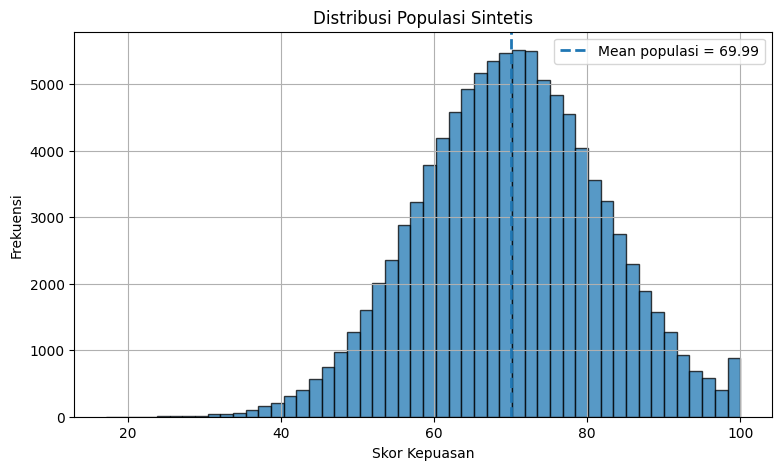

In [3]:
plt.hist(population, bins=50, edgecolor='black', alpha=0.75)
plt.axvline(pop_mean, linestyle='--', linewidth=2, label=f'Mean populasi = {pop_mean:.2f}')
plt.title('Distribusi Populasi Sintetis')
plt.xlabel('Skor Kepuasan')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## Mengambil Satu Sampel

Sekarang kita mengambil satu sampel berukuran 100 dari populasi. Nilai rata-rata sampel hampir pasti tidak persis sama dengan rata-rata populasi. Perbedaan ini disebut **sampling error**.

In [4]:
n = 100
sample = np.random.choice(population, size=n, replace=False)

sample_mean = np.mean(sample)
sampling_error = sample_mean - pop_mean

print(f"Mean sampel        : {sample_mean:.4f}")
print(f"Mean populasi      : {pop_mean:.4f}")
print(f"Sampling error     : {sampling_error:.4f}")

Mean sampel        : 71.8871
Mean populasi      : 69.9919
Sampling error     : 1.8952


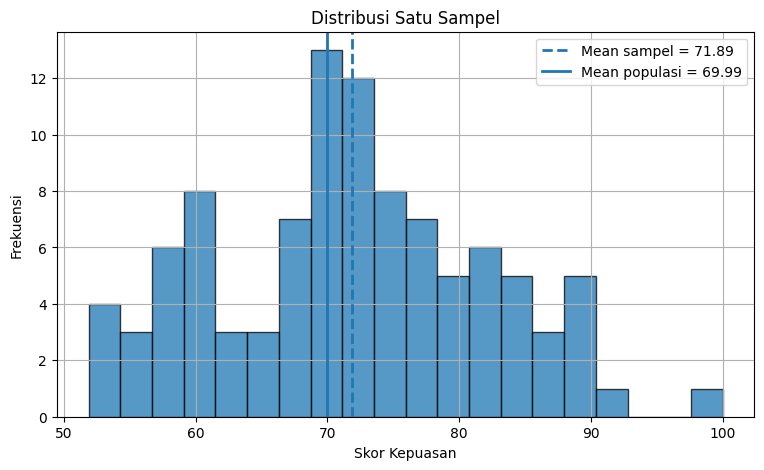

In [5]:
plt.hist(sample, bins=20, edgecolor='black', alpha=0.75)
plt.axvline(sample_mean, linestyle='--', linewidth=2, label=f'Mean sampel = {sample_mean:.2f}')
plt.axvline(pop_mean, linestyle='-', linewidth=2, label=f'Mean populasi = {pop_mean:.2f}')
plt.title('Distribusi Satu Sampel')
plt.xlabel('Skor Kepuasan')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## Checkpoint 1

Jawab secara singkat:

1. Apa perbedaan **parameter** dan **statistik**?
2. Mengapa mean sampel tidak harus sama dengan mean populasi?
3. Apa yang dimaksud dengan **sampling error**?
4. Jika ukuran sampel diperbesar, apakah sampling error pasti menjadi nol? Jelaskan.

In [ ]:
# Ruang jawaban Checkpoint 1
# Tulis jawaban Anda sebagai komentar di bawah ini.

# Bagian C — Sampling Methods

Pemilihan metode sampling menentukan kualitas inferensi. Sampel yang besar tetapi bias dapat menghasilkan kesimpulan yang buruk. Sebaliknya, sampel yang lebih kecil tetapi representatif sering lebih baik.

Pada bagian ini kita membahas beberapa metode sampling:

1. Simple Random Sampling
2. Systematic Sampling
3. Stratified Sampling
4. Cluster Sampling
5. Convenience Sampling sebagai contoh sampling bias

## C.1 Simple Random Sampling

Dalam **simple random sampling**, setiap anggota populasi memiliki peluang yang sama untuk terpilih. Metode ini menjadi dasar banyak teori inferensi statistik.

In [6]:
def simple_random_sampling(data, n):
    return np.random.choice(data, size=n, replace=False)

srs = simple_random_sampling(population, n=200)

print(f"Mean SRS: {np.mean(srs):.4f}")
print(f"Std SRS : {np.std(srs, ddof=1):.4f}")

Mean SRS: 69.4508
Std SRS : 11.5279


## C.2 Systematic Sampling

Dalam **systematic sampling**, kita memilih elemen berdasarkan interval tertentu, misalnya setiap elemen ke-`k` setelah titik awal acak.

Metode ini efisien, tetapi dapat bermasalah jika urutan data memiliki pola periodik.

In [7]:
def systematic_sampling(data, n):
    N = len(data)
    k = N // n
    start = np.random.randint(0, k)
    indices = np.arange(start, start + k*n, k)
    return data[indices]

sys_sample = systematic_sampling(population, n=200)

print(f"Mean Systematic: {np.mean(sys_sample):.4f}")
print(f"Std Systematic : {np.std(sys_sample, ddof=1):.4f}")

Mean Systematic: 68.5157
Std Systematic : 12.0953


## C.3 Stratified Sampling

Dalam **stratified sampling**, populasi dibagi menjadi beberapa strata, lalu sampel diambil dari setiap strata. Metode ini berguna ketika populasi heterogen dan kita ingin setiap kelompok terwakili.

Contoh: populasi pelanggan dibagi menjadi kelompok kepuasan rendah, sedang, dan tinggi.

In [8]:
# Membentuk strata berdasarkan skor kepuasan
low = population[population < 60]
medium = population[(population >= 60) & (population < 80)]
high = population[population >= 80]

print(len(low), len(medium), len(high))

20278 59416 20306


In [9]:
# Sampling proporsional berdasarkan ukuran strata
n_total = 300
n_low = int(n_total * len(low) / len(population))
n_medium = int(n_total * len(medium) / len(population))
n_high = n_total - n_low - n_medium

strat_sample = np.concatenate([
    np.random.choice(low, size=n_low, replace=False),
    np.random.choice(medium, size=n_medium, replace=False),
    np.random.choice(high, size=n_high, replace=False)
])

print(f"n low    : {n_low}")
print(f"n medium : {n_medium}")
print(f"n high   : {n_high}")
print(f"Mean Stratified Sample: {np.mean(strat_sample):.4f}")

n low    : 60
n medium : 178
n high   : 62
Mean Stratified Sample: 70.5415


## C.4 Cluster Sampling

Dalam **cluster sampling**, populasi dibagi ke dalam klaster. Beberapa klaster dipilih, lalu semua anggota atau sebagian anggota dalam klaster tersebut diamati.

Contoh: memilih beberapa kelas dari seluruh kelas di kampus, lalu mensurvei mahasiswa dalam kelas terpilih.

In [10]:
# Simulasi 100 klaster, masing-masing berisi 1000 anggota
clusters = np.array_split(population, 100)

selected_cluster_ids = np.random.choice(np.arange(100), size=8, replace=False)
cluster_sample = np.concatenate([clusters[i] for i in selected_cluster_ids])

print(f"Klaster terpilih: {selected_cluster_ids}")
print(f"Ukuran cluster sample: {len(cluster_sample)}")
print(f"Mean Cluster Sample : {np.mean(cluster_sample):.4f}")

Klaster terpilih: [73 53 29 20 98 40 75  6]
Ukuran cluster sample: 8000
Mean Cluster Sample : 69.8349


## C.5 Convenience Sampling dan Sampling Bias

**Convenience sampling** memilih data yang paling mudah diperoleh. Dalam praktik, ini sering terjadi, tetapi dapat menghasilkan bias.

Misalnya, survei kepuasan hanya diberikan kepada pelanggan yang aktif membuka aplikasi. Hasilnya mungkin terlalu optimistis karena pelanggan yang tidak puas sudah tidak aktif.

In [11]:
# Contoh bias: hanya mengambil individu dengan skor di atas 65
biased_population_frame = population[population > 65]
convenience_sample = np.random.choice(biased_population_frame, size=300, replace=False)

print(f"Mean populasi sebenarnya   : {pop_mean:.4f}")
print(f"Mean convenience sample    : {np.mean(convenience_sample):.4f}")
print(f"Bias estimasi              : {np.mean(convenience_sample) - pop_mean:.4f}")

Mean populasi sebenarnya   : 69.9919
Mean convenience sample    : 76.4532
Bias estimasi              : 6.4613


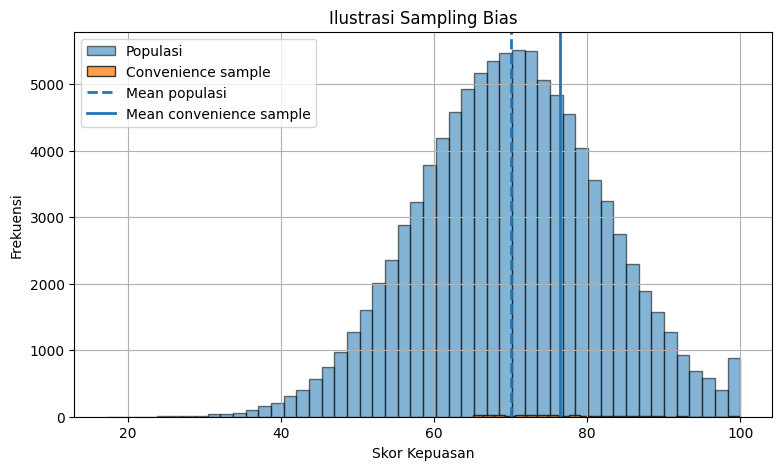

In [12]:
plt.hist(population, bins=50, alpha=0.55, edgecolor='black', label='Populasi')
plt.hist(convenience_sample, bins=25, alpha=0.75, edgecolor='black', label='Convenience sample')
plt.axvline(pop_mean, linestyle='--', linewidth=2, label='Mean populasi')
plt.axvline(np.mean(convenience_sample), linestyle='-', linewidth=2, label='Mean convenience sample')
plt.title('Ilustrasi Sampling Bias')
plt.xlabel('Skor Kepuasan')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## Checkpoint 2

Tentukan metode sampling yang paling tepat untuk masing-masing kasus berikut, lalu jelaskan alasannya:

1. Peneliti ingin mengetahui rata-rata pendapatan mahasiswa dari seluruh fakultas, dan setiap fakultas harus terwakili.
2. Data pelanggan tersusun acak dalam database, lalu analis mengambil setiap pelanggan ke-100.
3. Peneliti memilih 5 sekolah secara acak, lalu mengukur seluruh siswa di sekolah tersebut.
4. Survei dilakukan hanya kepada pengguna yang sedang online pada jam tertentu.5. Kasus mana yang paling berisiko menghasilkan bias?

In [ ]:
# Ruang jawaban Checkpoint 2

# Bagian D — Repeated Sampling dan Sampling Error

Inferensi statistik bergantung pada ide bahwa jika kita mengambil banyak sampel dari populasi yang sama, statistik sampel akan berubah-ubah. Variabilitas inilah yang menjadi dasar konsep **standard error**.

In [13]:
def repeated_sample_means(data, n, B=1000):
    means = []
    for _ in range(B):
        samp = np.random.choice(data, size=n, replace=False)
        means.append(np.mean(samp))
    return np.array(means)

means_n30 = repeated_sample_means(population, n=30, B=3000)

print(f"Rata-rata dari mean sampel: {np.mean(means_n30):.4f}")
print(f"Mean populasi             : {pop_mean:.4f}")
print(f"Std mean sampel           : {np.std(means_n30, ddof=1):.4f}")

Rata-rata dari mean sampel: 69.9488
Mean populasi             : 69.9919
Std mean sampel           : 2.1399


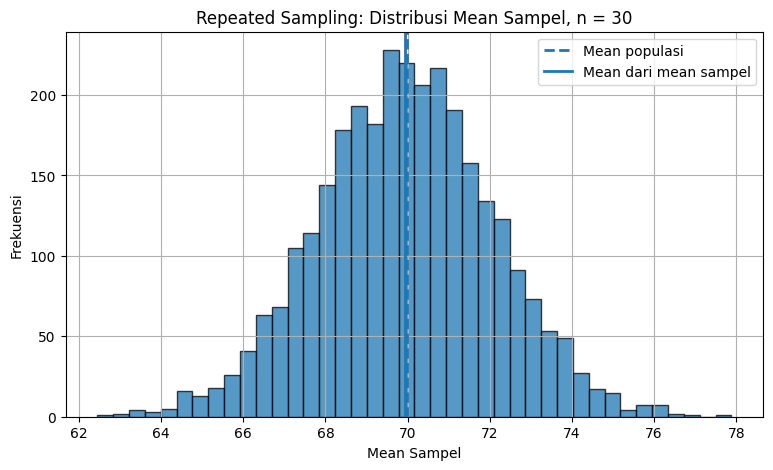

In [14]:
plt.hist(means_n30, bins=40, edgecolor='black', alpha=0.75)
plt.axvline(pop_mean, linestyle='--', linewidth=2, label='Mean populasi')
plt.axvline(np.mean(means_n30), linestyle='-', linewidth=2, label='Mean dari mean sampel')
plt.title('Repeated Sampling: Distribusi Mean Sampel, n = 30')
plt.xlabel('Mean Sampel')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## Interpretasi

Histogram di atas bukan distribusi data asli, melainkan distribusi dari rata-rata sampel. Distribusi ini disebut **sampling distribution of the sample mean**.

Perhatikan bahwa:

- pusat distribusi mendekati mean populasi;
- sebarannya lebih kecil daripada sebaran data asli;
- sebaran tersebut menunjukkan ketidakpastian estimator mean.

## Checkpoint 3

Jawab pertanyaan berikut:

1. Apa perbedaan distribusi populasi dan sampling distribution?
2. Mengapa sampling distribution dari mean memiliki sebaran lebih kecil daripada distribusi data asli?
3. Apa arti praktis dari standard error?

In [ ]:
# Ruang jawaban Checkpoint 3

# Bagian E — Standard Error dan Pengaruh Ukuran Sampel

Standard error menunjukkan seberapa jauh estimator, misalnya rata-rata sampel, dapat bervariasi dari satu sampel ke sampel lain.


Semakin besar ukuran sampel, standard error semakin kecil.

In [21]:
sizes = [5, 10, 20, 30, 50, 100, 200, 500]
se_empirical = []
se_theoretical = []

for n in sizes:
    means = repeated_sample_means(population, n=n, B=2000)
    se_empirical.append(np.std(means, ddof=1))
    se_theoretical.append(pop_std / np.sqrt(n))

se_df = pd.DataFrame({
    'n': sizes,
    'SE empirical': se_empirical,
    'SE theoretical': se_theoretical
})

se_df

,n,SE empirical,SE theoretical
0,5,5.391476,5.334268
1,10,3.872782,3.771897
2,20,2.670599,2.667134
3,30,2.151460,2.177706
4,50,1.677391,1.686844
5,100,1.188696,1.192779
6,200,0.846289,0.843422
7,500,0.523548,0.533427


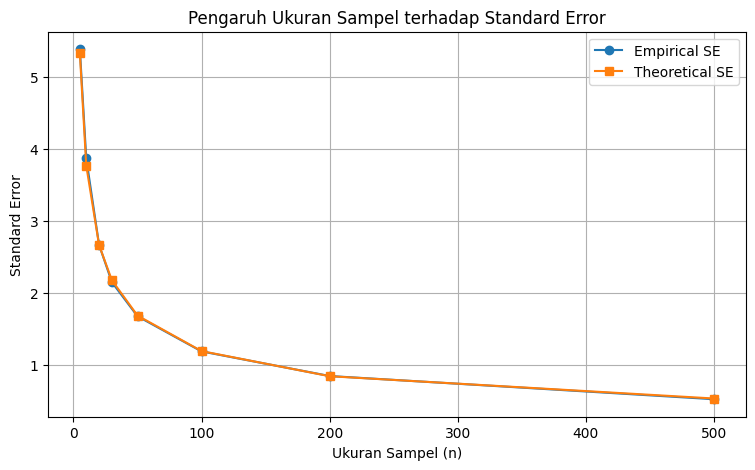

In [22]:
plt.plot(se_df['n'], se_df['SE empirical'], marker='o', label='Empirical SE')
plt.plot(se_df['n'], se_df['SE theoretical'], marker='s', label='Theoretical SE')
plt.title('Pengaruh Ukuran Sampel terhadap Standard Error')
plt.xlabel('Ukuran Sampel (n)')
plt.ylabel('Standard Error')
plt.legend()
plt.show()

## Checkpoint 5

Berdasarkan tabel dan grafik di atas:

1. Apa yang terjadi pada standard error ketika ukuran sampel meningkat?
2. Mengapa menaikkan ukuran sampel dari 10 ke 40 tidak membuat standard error turun menjadi sepersepuluh?
3. Jelaskan makna praktis dari hubungan $SE \propto 1/\sqrt{n}$.

In [ ]:
# Ruang jawaban Checkpoint 5

# Bagian F — Confidence Interval untuk Mean

Confidence interval adalah interval estimasi yang mempertimbangkan ketidakpastian sampel.

Jika standar deviasi populasi tidak diketahui, kita menggunakan distribusi t:

$$ar{x} \pm t_{lpha/2, n-1}
rac{s}{\sqrt{n}}.$$

Dalam praktik, t-interval sangat umum karena standar deviasi populasi hampir selalu tidak diketahui.

In [23]:
def confidence_interval_mean(sample, confidence=0.95):
    n = len(sample)
    mean = np.mean(sample)
    s = np.std(sample, ddof=1)
    alpha = 1 - confidence
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin_error = t_crit * s / np.sqrt(n)
    return mean, mean - margin_error, mean + margin_error, margin_error

sample_ci = np.random.choice(population, size=40, replace=False)
mean_ci, lower_ci, upper_ci, me_ci = confidence_interval_mean(sample_ci, confidence=0.95)

print(f"Mean sampel       : {mean_ci:.4f}")
print(f"Margin of error   : {me_ci:.4f}")
print(f"CI 95%            : ({lower_ci:.4f}, {upper_ci:.4f})")
print(f"Mean populasi     : {pop_mean:.4f}")

Mean sampel       : 67.6133
Margin of error   : 3.1049
CI 95%            : (64.5085, 70.7182)
Mean populasi     : 69.9919


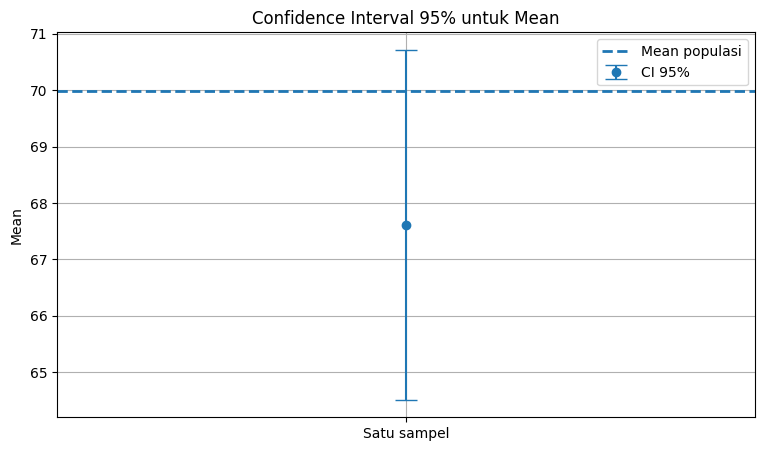

In [24]:
plt.errorbar(x=1, y=mean_ci, yerr=me_ci, fmt='o', capsize=8, label='CI 95%')
plt.axhline(pop_mean, linestyle='--', linewidth=2, label='Mean populasi')
plt.xlim(0.5, 1.5)
plt.xticks([1], ['Satu sampel'])
plt.ylabel('Mean')
plt.title('Confidence Interval 95% untuk Mean')
plt.legend()
plt.show()

## Interpretasi Confidence Interval yang Benar

Interpretasi yang benar:

> Jika proses sampling dan pembentukan interval diulang berkali-kali, sekitar 95% interval yang terbentuk akan memuat parameter populasi yang benar.

Interpretasi yang kurang tepat:

> Ada probabilitas 95% bahwa mean populasi berada dalam interval ini.

Dalam pendekatan frequentist, mean populasi adalah nilai tetap. Yang acak adalah intervalnya, karena interval berubah dari sampel ke sampel.

## F.1 Simulasi Banyak Confidence Interval

Kita akan mengambil banyak sampel, membangun interval untuk masing-masing sampel, lalu memeriksa berapa banyak interval yang memuat mean populasi.

In [25]:
np.random.seed(789)
B = 100
n = 30
intervals = []
contains_mean = []

for b in range(B):
    samp = np.random.choice(population, size=n, replace=False)
    mean, lower, upper, me = confidence_interval_mean(samp, confidence=0.95)
    intervals.append((mean, lower, upper))
    contains_mean.append(lower <= pop_mean <= upper)

coverage_rate = np.mean(contains_mean)
print(f"Coverage dari {B} interval: {coverage_rate:.3f}")

Coverage dari 100 interval: 0.920


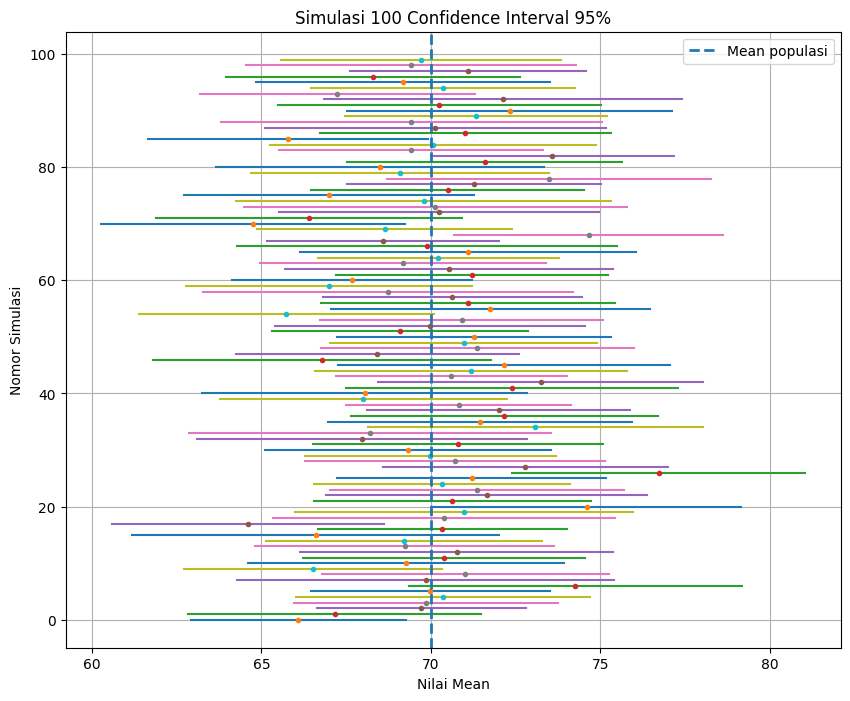

In [26]:
plt.figure(figsize=(10, 8))
for i, ((mean, lower, upper), ok) in enumerate(zip(intervals, contains_mean)):
    plt.plot([lower, upper], [i, i], linewidth=1.5)
    plt.plot(mean, i, 'o', markersize=3)

plt.axvline(pop_mean, linestyle='--', linewidth=2, label='Mean populasi')
plt.title('Simulasi 100 Confidence Interval 95%')
plt.xlabel('Nilai Mean')
plt.ylabel('Nomor Simulasi')
plt.legend()
plt.show()

## Checkpoint 6

Jawab pertanyaan berikut:

1. Mengapa tidak semua confidence interval memuat mean populasi?
2. Apa arti confidence level 95% dalam simulasi di atas?
3. Jika confidence level dinaikkan menjadi 99%, apa yang terjadi pada lebar interval?
4. Mana yang lebih presisi: interval 90% atau 99%? Mana yang lebih sering memuat parameter?

In [ ]:
# Ruang jawaban Checkpoint 6

# Bagian G — Confidence Interval untuk Proporsi

Selain mean, inferensi sering digunakan untuk proporsi.

Misalnya:

- proporsi pelanggan yang puas;
- proporsi mahasiswa yang lulus;
- proporsi transaksi yang fraud;
- proporsi saham yang memenuhi kriteria tertentu.

Untuk sampel besar, CI proporsi dapat ditulis:

$$\hat{p} \pm z_{lpha/2}\sqrt{
rac{\hat{p}(1-\hat{p})}{n}}.$$

In [27]:
# Simulasi populasi biner: 1 = puas, 0 = tidak puas
np.random.seed(321)
true_p = 0.68
binary_population = np.random.binomial(n=1, p=true_p, size=100_000)

print(f"Proporsi populasi sebenarnya: {np.mean(binary_population):.4f}")

Proporsi populasi sebenarnya: 0.6796


In [28]:
def confidence_interval_proportion(x, n, confidence=0.95):
    p_hat = x / n
    alpha = 1 - confidence
    z_crit = stats.norm.ppf(1 - alpha/2)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    margin_error = z_crit * se
    return p_hat, p_hat - margin_error, p_hat + margin_error, margin_error

n = 200
samp_bin = np.random.choice(binary_population, size=n, replace=False)
x = np.sum(samp_bin)

p_hat, lower_p, upper_p, me_p = confidence_interval_proportion(x, n, confidence=0.95)

print(f"Jumlah sukses       : {x}")
print(f"p-hat               : {p_hat:.4f}")
print(f"CI 95% proporsi     : ({lower_p:.4f}, {upper_p:.4f})")
print(f"Proporsi populasi   : {np.mean(binary_population):.4f}")

Jumlah sukses       : 134
p-hat               : 0.6700
CI 95% proporsi     : (0.6048, 0.7352)
Proporsi populasi   : 0.6796


## Checkpoint 7

Sebuah survei terhadap 500 responden menunjukkan 315 responden menyatakan puas.

1. Hitung estimasi proporsi kepuasan.
2. Bangun confidence interval 95% untuk proporsi.
3. Jelaskan interpretasinya dalam konteks survei.
4. Apakah hasil ini membuktikan bahwa tepat 63% populasi puas? Jelaskan.

In [ ]:
# Ruang kerja Checkpoint 7
# Gunakan fungsi confidence_interval_proportion di atas.

x = 315
n = 500

# Tulis kode Anda di bawah ini.

# Bagian H — Bootstrap Inference

Bootstrap adalah metode resampling yang mengambil sampel ulang dari data sampel dengan pengembalian. Bootstrap berguna ketika distribusi estimator sulit diturunkan secara analitik.

Ide utamanya:

1. ambil satu sampel dari populasi;
2. ambil resample dari sampel tersebut dengan replacement;
3. hitung statistik pada setiap resample;
4. gunakan distribusi statistik bootstrap untuk mengukur ketidakpastian.

In [29]:
np.random.seed(987)
observed_sample = np.random.choice(right_skewed_population, size=80, replace=False)

print(f"Mean observed sample: {np.mean(observed_sample):.4f}")
print(f"Median observed sample: {np.median(observed_sample):.4f}")

Mean observed sample: 9.0335
Median observed sample: 5.9210


In [30]:
def bootstrap_statistic(sample, statistic_function=np.mean, B=3000):
    stats_boot = []
    n = len(sample)
    for _ in range(B):
        resample = np.random.choice(sample, size=n, replace=True)
        stats_boot.append(statistic_function(resample))
    return np.array(stats_boot)

boot_means = bootstrap_statistic(observed_sample, np.mean, B=5000)
boot_medians = bootstrap_statistic(observed_sample, np.median, B=5000)

print(f"Bootstrap mean of means   : {np.mean(boot_means):.4f}")
print(f"Bootstrap SE for mean     : {np.std(boot_means, ddof=1):.4f}")
print(f"Bootstrap mean of medians : {np.mean(boot_medians):.4f}")
print(f"Bootstrap SE for median   : {np.std(boot_medians, ddof=1):.4f}")

Bootstrap mean of means   : 9.0210
Bootstrap SE for mean     : 0.9747
Bootstrap mean of medians : 5.9954
Bootstrap SE for median   : 0.9577


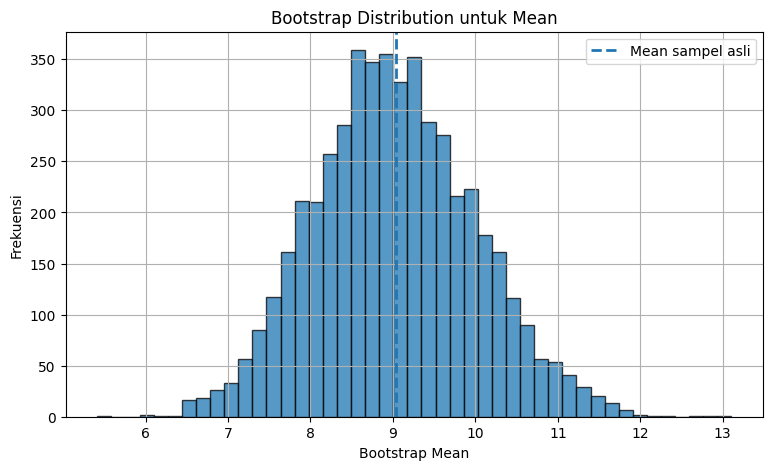

In [31]:
plt.hist(boot_means, bins=45, edgecolor='black', alpha=0.75)
plt.axvline(np.mean(observed_sample), linestyle='--', linewidth=2, label='Mean sampel asli')
plt.title('Bootstrap Distribution untuk Mean')
plt.xlabel('Bootstrap Mean')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

In [32]:
boot_ci_mean = np.percentile(boot_means, [2.5, 97.5])
boot_ci_median = np.percentile(boot_medians, [2.5, 97.5])

print(f"Bootstrap CI 95% untuk mean   : ({boot_ci_mean[0]:.4f}, {boot_ci_mean[1]:.4f})")
print(f"Bootstrap CI 95% untuk median : ({boot_ci_median[0]:.4f}, {boot_ci_median[1]:.4f})")

Bootstrap CI 95% untuk mean   : (7.2131, 11.0158)
Bootstrap CI 95% untuk median : (4.3051, 7.9197)


## Checkpoint 8

Jawab pertanyaan berikut:

1. Apa perbedaan sampling biasa dan bootstrap resampling?
2. Mengapa bootstrap menggunakan replacement?
3. Dalam kasus distribusi miring ke kanan, mengapa median bisa menjadi ukuran pusat yang menarik?
4. Apa kelebihan bootstrap dibanding hanya menggunakan rumus normal/t klasik?

In [ ]:
# Ruang jawaban Checkpoint 8

# Bagian I — Mini Case Study: Estimasi Rata-Rata Return Harian

Pada bagian ini kita menggunakan data sintetis yang menyerupai return harian. Tujuannya bukan untuk membuat model keuangan lengkap, tetapi untuk menunjukkan bagaimana sampling dan confidence interval digunakan dalam konteks data science.

In [33]:
np.random.seed(2024)

# Simulasi return harian dengan distribusi t untuk mencerminkan heavy tail
returns = stats.t.rvs(df=5, loc=0.0008, scale=0.015, size=1500)

returns_df = pd.DataFrame({'daily_return': returns})
returns_df.head()

,daily_return
0,0.022120
1,0.006814
2,-0.071298
3,0.006972
4,0.011412


In [34]:
returns_df['daily_return'].describe()

,daily_return
count,1500.000000
mean,0.000812
std,0.021853
min,-0.281978
25%,-0.010970
50%,0.001180
75%,0.012235
max,0.156882


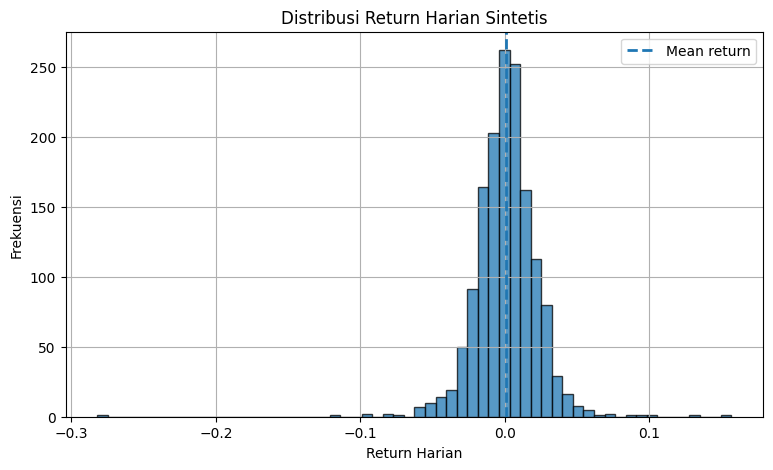

In [35]:
plt.hist(returns_df['daily_return'], bins=60, edgecolor='black', alpha=0.75)
plt.axvline(returns_df['daily_return'].mean(), linestyle='--', linewidth=2, label='Mean return')
plt.title('Distribusi Return Harian Sintetis')
plt.xlabel('Return Harian')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## I.1 Confidence Interval untuk Mean Return

Kita ambil sampel 120 hari perdagangan dan membangun confidence interval untuk mean return harian.

In [36]:
sample_returns = returns_df['daily_return'].sample(n=120, random_state=42).values

mean_r, lower_r, upper_r, me_r = confidence_interval_mean(sample_returns, confidence=0.95)

print(f"Mean return sampel       : {mean_r:.6f}")
print(f"CI 95% mean return       : ({lower_r:.6f}, {upper_r:.6f})")
print(f"Margin of error          : {me_r:.6f}")

Mean return sampel       : -0.001690
CI 95% mean return       : (-0.005428, 0.002048)
Margin of error          : 0.003738


## I.2 Bootstrap CI untuk Mean Return

Karena return sering tidak normal dan memiliki ekor tebal, bootstrap dapat digunakan sebagai pembanding.

In [37]:
boot_return_means = bootstrap_statistic(sample_returns, np.mean, B=5000)
boot_return_ci = np.percentile(boot_return_means, [2.5, 97.5])

print(f"Bootstrap CI 95% mean return: ({boot_return_ci[0]:.6f}, {boot_return_ci[1]:.6f})")

Bootstrap CI 95% mean return: (-0.005476, 0.001776)


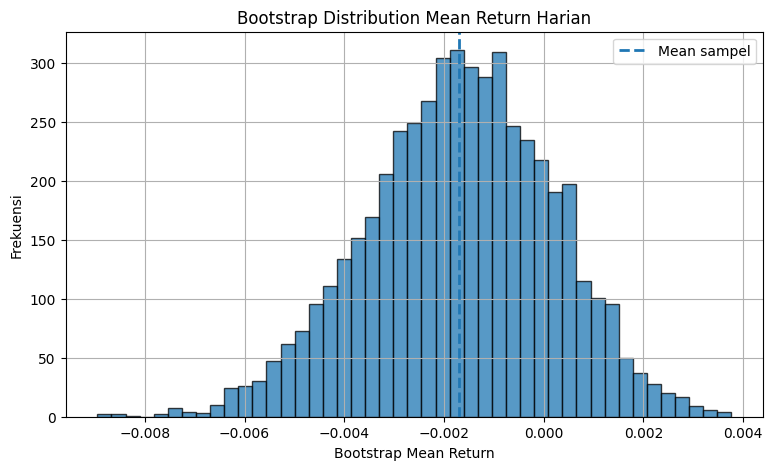

In [38]:
plt.hist(boot_return_means, bins=45, edgecolor='black', alpha=0.75)
plt.axvline(np.mean(sample_returns), linestyle='--', linewidth=2, label='Mean sampel')
plt.title('Bootstrap Distribution Mean Return Harian')
plt.xlabel('Bootstrap Mean Return')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## Checkpoint 9

Berdasarkan mini case study return harian:

1. Apakah interval mean return mengandung nol?
2. Jika interval mengandung nol, apa artinya secara praktis?
3. Mengapa inferensi terhadap return perlu hati-hati?
4. Mengapa bootstrap dapat menjadi pendekatan yang berguna untuk data return?

In [ ]:
# Ruang jawaban Checkpoint 9

# Bagian J — Kesalahan Umum dalam Inferensi Statistik

Beberapa kesalahan umum:

1. Menganggap sampel besar selalu bebas bias.
2. Menganggap confidence interval adalah probabilitas parameter berada dalam interval.
3. Melupakan bahwa standard error mengukur variasi estimator, bukan variasi data mentah.
4. Menggunakan inferensi klasik tanpa memeriksa asumsi konteks.
5. Mengabaikan desain sampling.

Dalam data science, kualitas inferensi sangat bergantung pada kualitas data dan proses pengambilannya.

# Bagian K — Latihan Mandiri

Kerjakan latihan berikut untuk memperkuat pemahaman.

## Latihan 1 — Sampling Methods

Sebuah universitas memiliki 5 fakultas dengan jumlah mahasiswa berbeda. Peneliti ingin mengestimasi rata-rata pengeluaran bulanan mahasiswa.

1. Metode sampling apa yang paling sesuai?
2. Mengapa simple random sampling mungkin kurang ideal jika ukuran fakultas sangat berbeda?
3. Bagaimana cara membuat sampling proporsional berdasarkan fakultas?

In [ ]:
# Ruang kerja Latihan 1

## Latihan 2 — Sampling Distribution

Buat populasi sintetis berukuran 50.000 dari distribusi gamma dengan parameter bebas.

1. Visualisasikan distribusi populasinya.
2. Ambil 3000 sampel berukuran 10, lalu simpan mean setiap sampel.
3. Ulangi untuk ukuran sampel 50 dan 200.
4. Bandingkan bentuk sampling distribution.

In [ ]:
# Ruang kerja Latihan 2

## Latihan 3 — Standard Error

Gunakan populasi dari Latihan 2.

1. Hitung standard error teoritis untuk n = 10, 50, dan 200.
2. Hitung standard error empiris dari simulasi.
3. Bandingkan keduanya.
4. Jelaskan hasilnya.

In [ ]:
# Ruang kerja Latihan 3

## Latihan 4 — Confidence Interval Mean

Ambil satu sampel berukuran 40 dari populasi gamma pada Latihan 2.

1. Hitung mean sampel.
2. Bangun CI 90%, 95%, dan 99%.
3. Bandingkan lebar interval.
4. Jelaskan hubungan confidence level dan margin of error.

In [ ]:
# Ruang kerja Latihan 4

## Latihan 5 — Confidence Interval Proporsi

Dalam survei 800 responden, 536 menyatakan puas terhadap layanan digital.

1. Hitung proporsi sampel.
2. Bangun confidence interval 95%.
3. Interpretasikan hasilnya.
4. Apa yang terjadi jika ukuran sampel hanya 80 dengan proporsi yang sama?

In [ ]:
# Ruang kerja Latihan 5

## Latihan 6 — Bootstrap

Gunakan data return harian sintetis pada Bagian J.

1. Ambil sampel 60 return.
2. Bangun bootstrap CI 95% untuk mean.
3. Bangun bootstrap CI 95% untuk median.
4. Bandingkan hasilnya dan jelaskan mana yang lebih robust.

In [ ]:
# Ruang kerja Latihan 6

# TUGAS

Gunakan salah satu:

1. data saham (Yahoo Finance)
2. data ekonomi (inflasi, GDP, dll)
3. dataset publik yang lain

Kemudian
1. Ambil data (minimal 100 observasi), tentukan mean dan std

2. Ambil beberapa sampel acak dan bangun sampling distribution, confidence interval, dan interpretasikan hasil

3. Jawab pertanyaan analitis berikut

    a. Apakah sampel cukup merepresentasikan populasi?

    b. Seberapa besar ketidakpastian estimasi?

    c. Apa implikasi untuk pengambilan keputusan?